In [70]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


In [71]:
# GENERACIÓN DE DATOS
def lorenz(t,state, sigma=10, rho=28, beta=8/3):
    x, y, z = state
    return [sigma * (y - x), x * (rho - z) - y, x * y - beta * z]

dt = 0.01
t_span = (0, 25)
t_eval = np.arange(t_span[0], t_span[1], dt)
x0 = [-8, 7, 27]

sol = solve_ivp(lorenz, t_span, x0, t_eval=t_eval)
X_real = sol.y.T

# Medicion parcial: SOLO MEDIMOS LA VARIABLE X
y_medido = X_real[:, 0] 


In [72]:
#ESPACIO DE RETARDOS (TAKENS / HANKEL)
n_delays = 15  # Dimensión de incrustación
tau = 5        # Retraso temporal

r = len(y_medido) - (n_delays - 1) * tau
X_delay = np.zeros((r, n_delays)) 
for i in range(n_delays):
    X_delay[:, i] = y_medido[i * tau : r + i * tau]



In [73]:
#REDUCCIÓN SVD INICIAL 

print("Aplicando SVD...")
U, S, Vt = np.linalg.svd(X_delay, full_matrices=False)
p = 7 # Mantenemos 7 componentes principales
Up = Vt.T[:, :p]

# Datos proyectados al subespacio intermedio
V_red = X_delay @ Up 

# Convertimos a tensores (para poder entrenar la red neuronal con PyTorch)
V_tensor = torch.tensor(V_red, dtype=torch.float32)
Y_medido_tensor = torch.tensor(X_delay[:, 0], dtype=torch.float32).view(-1, 1)


Aplicando SVD...


In [74]:
# DEFINICIÓN DEL MODELO SINDY-AUTOENCODER
class SINDyAutoencoder(nn.Module):
    def __init__(self, input_dim=7, latent_dim=3, poly_order=2):  #Objetivo: comprimir 7 variables de retardo a 3 variables latentes
        super(SINDyAutoencoder, self).__init__()
        
        # Encoder. Comprimo 7 variables en 3
        self.encoder = nn.Sequential(   
            nn.Linear(input_dim, 32),  #Capa oculta con 32 neuronas donde cojo las 7 variables de entrada y 
                                        #las combino linealmente para obtener 32 números
            nn.ELU(),                   #Función de activación ELU
            nn.Linear(32, 32),         #Toma las 32 salidas de la capa anterior y
                                       # las vuelve a mezclar mediante otra combinación lineal, entregando otros 32 números
            nn.ELU(),
            nn.Linear(32, latent_dim)  #Tercera y ultima capa que me devuelve las 3(latent_dim)variables latentes que me interesan
        )
        
        # Decoder. Reconstruyo 3 variables latentes en 7
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.ELU(),
            nn.Linear(32, 32),
            nn.ELU(),
            nn.Linear(32, input_dim)
        )
        
        # Matriz SINDy (Parámetros entrenables)
        # Para m=3 variables y grado 2, hay 10 funciones en la librería
        self.n_features = 10 
        self.xi = nn.Parameter(torch.randn(self.n_features, latent_dim) * 0.1)  #Inicializo Xi con valores pequeños
        
    def build_library(self, z):
        # Construye la librería de funciones no lineales Θ(z) polinomial hasta grado 2
        bloques = z.shape[0]
        ones = torch.ones(bloques, 1)
        z1, z2, z3 = z[:, 0:1], z[:, 1:2], z[:, 2:3]
        
        # Funciones: [1, x, y, z, x^2, xy, xz, y^2, yz, z^2]
        return torch.cat([
            ones, z1, z2, z3, 
            z1*z1, z1*z2, z1*z3, 
            z2*z2, z2*z3, 
            z3*z3
        ], dim=1)

    def forward(self, v):
        # 1. Transformación al espacio latente
        z = self.encoder(v)
        # 2. Reconstrucción
        v_recon = self.decoder(z)
        # 3. Derivada temporal descubierta por SINDy
        theta_z = self.build_library(z)
        dz_sindy = theta_z @ self.xi
        
        return z, v_recon, dz_sindy


In [75]:
# ENTRENAMIENTO CON LA FUNCIÓN DE PÉRDIDA
model = SINDyAutoencoder(input_dim=p, latent_dim=3)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

iteraciones= 1500
dt_tensor = torch.tensor(dt, dtype=torch.float32)

# Pesos de la función de pérdida del artículo
lam_recon = 1.0
lam_sindy = 0.1
lam_z1 = 0.5
lam_l1 = 1e-4

print("Iniciando el entrenamiento del Deep Delay Autoencoder...")
for iter in range(iteraciones):
    optimizer.zero_grad()  #Pongo a 0 los gradientes de los parámetros entrenables para que no se acumulen de una iteración a otra
    
    # Forward pass
    z, v_recon, dz_sindy = model(V_tensor)
    
    # Derivada temporal latente empírica (diferencias finitas centrales)
    dz_empirico = torch.zeros_like(z)                       #Crea un contenedor vacío del mismo tamaño que z
    dz_empirico[1:-1] = (z[2:] - z[:-2]) / (2 * dt_tensor) 
    dz_empirico[0] = (z[1] - z[0]) / dt_tensor
    dz_empirico[-1] = (z[-1] - z[-2]) / dt_tensor
    
    # 1. Pérdida de Reconstrucción (Decoder)
    loss_recon = nn.functional.mse_loss(v_recon, V_tensor)  #Error cuadratidoc medio entre el dato original (V_tensor) y el que reconstruyó el Decoder (v_recon)
    
    # 2. Pérdida SINDy. Compara las derivadas que predice dz_sindy contra los cambios reales que están sufriendo los datos (dz_empirico)
    loss_sindy = nn.functional.mse_loss(dz_sindy, dz_empirico)
    
    # 3. Pérdida de Primera Componente (z_1 debe igualar a y_medido). Ancla el espacio latente al mundo real (lo dice el artículo)
    # Estandarizamos un poco para ayudar al optimizador
    loss_z1 = nn.functional.mse_loss(z[:, 0:1], Y_medido_tensor)
    
    # 4. Regularización L1 (Para forzar una matriz dispersa)
    loss_l1 = torch.mean(torch.abs(model.xi))
    
    # FUNCIÓN DE PÉRDIDA TOTAL
    loss = (lam_recon * loss_recon) + (lam_sindy * loss_sindy) + (lam_z1 * loss_z1) + (lam_l1 * loss_l1)
           
    loss.backward()
    optimizer.step()
    
    if (iter+1) % 300 == 0:
        print(f"Epoch {iter+1}/{iteraciones} | Total Loss: {loss.item():.4f} | Recon: {loss_recon.item():.4f} | SINDy: {loss_sindy.item():.4f} | z1: {loss_z1.item():.4f}")

# ==========================================


Iniciando el entrenamiento del Deep Delay Autoencoder...
Epoch 300/1500 | Total Loss: 21.2185 | Recon: 7.4906 | SINDy: 74.5484 | z1: 12.5460
Epoch 600/1500 | Total Loss: 8.5230 | Recon: 2.6355 | SINDy: 25.6253 | z1: 6.6498
Epoch 900/1500 | Total Loss: 6.5968 | Recon: 2.0623 | SINDy: 20.6550 | z1: 4.9379
Epoch 1200/1500 | Total Loss: 5.6550 | Recon: 1.8166 | SINDy: 17.8259 | z1: 4.1116
Epoch 1500/1500 | Total Loss: 5.0620 | Recon: 1.6369 | SINDy: 16.1205 | z1: 3.6261


In [76]:
# DESCUBRIMIENTO DE ECUACIONES
model.eval()
z_final, _, _ = model(V_tensor)
Xi_final = model.xi.detach().numpy()

# Mostrar la matriz descubierta
feature_names = ['1', 'z1', 'z2', 'z3', 'z1^2', 'z1z2', 'z1z3', 'z2^2', 'z2z3', 'z3^2']

print("\n--- ECUACIONES DESCUBIERTAS POR SINDY EN EL ESPACIO LATENTE ---")
# Aplicamos un pequeño umbral para simular el Sequentially Thresholded Least Squares
umbral = 0.1 
for i, var in enumerate(['dz1/dt', 'dz2/dt', 'dz3/dt']):
    ecuacion = f"{var} = "
    terminos = []
    for j, coef in enumerate(Xi_final[:, i]):
        if abs(coef) > umbral:
            terminos.append(f"{coef:.3f}*{feature_names[j]}")
    if not terminos:
        ecuacion += "0"
    else:
        ecuacion += " + ".join(terminos)
    print(ecuacion)



--- ECUACIONES DESCUBIERTAS POR SINDY EN EL ESPACIO LATENTE ---
dz1/dt = -1.025*z1 + -0.557*z2 + -0.566*z3 + -0.261*z1^2 + 0.210*z1z2 + 0.539*z1z3 + -0.604*z2^2 + 0.622*z2z3 + 0.643*z3^2
dz2/dt = -0.553*1 + 0.373*z1 + 0.249*z2 + -0.159*z3 + -0.331*z1^2 + -0.174*z1z2 + -0.167*z1z3 + -0.350*z2^2 + 0.571*z3^2
dz3/dt = 0.554*1 + 0.111*z1 + 0.254*z2 + -0.354*z3 + 0.103*z1^2 + -0.195*z1z2 + -0.276*z1z3 + -0.128*z2z3 + -0.183*z3^2


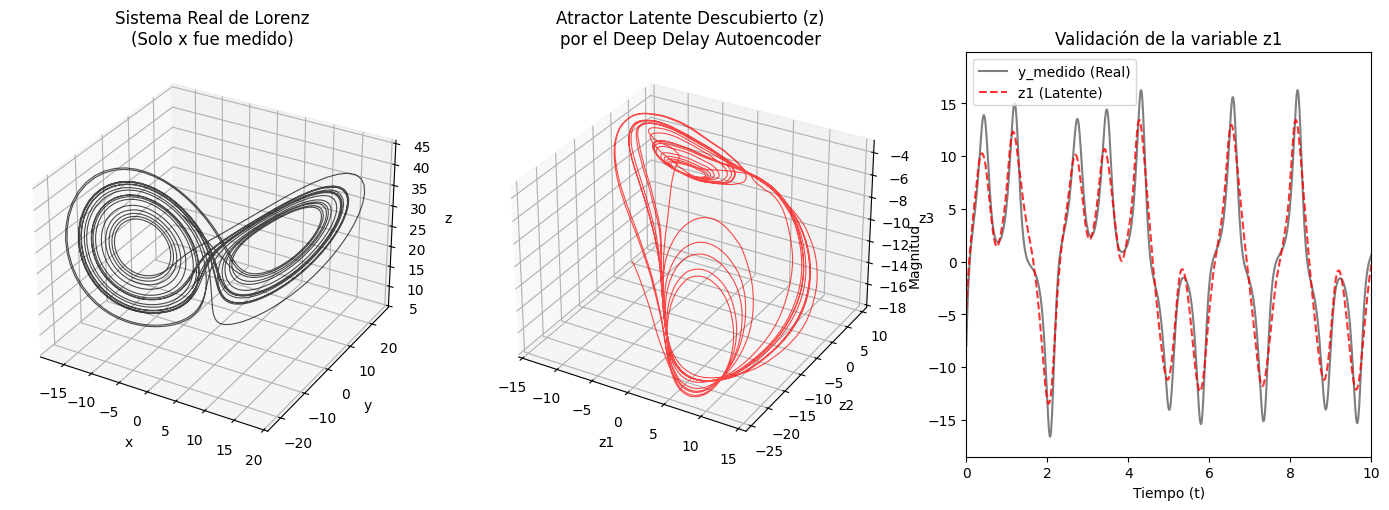

In [77]:
# Graficos
z_np = z_final.detach().numpy()

fig = plt.figure(figsize=(14, 5))

# Subplot 1: Sistema de Lorenz Real (Variables ocultas)
ax1 = fig.add_subplot(131, projection='3d')
ax1.plot(X_real[:r, 0], X_real[:r, 1], X_real[:r, 2], color='black', alpha=0.7, linewidth=0.8)
ax1.set_title("Sistema Real de Lorenz\n(Solo x fue medido)")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_zlabel("z")

# Subplot 2: Atractor Latente Descubierto (z)
ax2 = fig.add_subplot(132, projection='3d')
ax2.plot(z_np[:, 0], z_np[:, 1], z_np[:, 2], color='red', alpha=0.7, linewidth=0.8)
ax2.set_title("Atractor Latente Descubierto (z)\npor el Deep Delay Autoencoder")
ax2.set_xlabel("z1")
ax2.set_ylabel("z2")
ax2.set_zlabel("z3")

# Subplot 3: Comprobación de la Pérdida de 1ra Componente
ax3 = fig.add_subplot(133)
ax3.plot(t_eval[:r], X_delay[:, 0], 'k-', label='y_medido (Real)', alpha=0.5)
ax3.plot(t_eval[:r], z_np[:, 0], 'r--', label='z1 (Latente)', alpha=0.8)
ax3.set_title("Validación de la variable z1")
ax3.set_xlabel("Tiempo (t)")
ax3.set_ylabel("Magnitud")
ax3.set_xlim(0, 10)
ax3.legend()

plt.tight_layout()
plt.show()